In [1]:
import pandas as pd

# ====================== 1. Chargement des données ======================
print("Chargement du fichier radio_signatures_large.csv...")
df = pd.read_csv('radio_signatures_large.csv')

print(f"Nombre de signatures chargées : {len(df)}")
print(f"Nombre de navires uniques : {df['mmsi'].nunique()}")

# ====================== 2. Agrégation par MMSI ======================
print("\nAgrégation des signatures radio par navire...")

agg_dict = {
    'frequency': ['mean', 'min', 'max', 'std'],
    'bandwidth': 'mean',
    'power': 'mean',
    'signal_strength': 'mean',
    'signal_to_noise_ratio': 'mean',
    'noise_level': 'mean',
    'signature_id': 'count'  # nombre de signatures
}

# Renommer les colonnes après agrégation
profiles = df.groupby('mmsi').agg(agg_dict).reset_index()

# Aplatir les noms de colonnes multi-index
profiles.columns = [
    'mmsi',
    'freq_mean_mhz', 'freq_min_mhz', 'freq_max_mhz', 'freq_std_mhz',
    'bandwidth_mean_khz',
    'power_mean_watts',
    'signal_strength_mean_dbm',
    'snr_mean_db',
    'noise_level_mean_dbm',
    'num_signatures'
]

# Arrondir les valeurs pour plus de lisibilité
profiles = profiles.round({
    'freq_mean_mhz': 4,
    'freq_min_mhz': 4,
    'freq_max_mhz': 4,
    'freq_std_mhz': 4,
    'bandwidth_mean_khz': 2,
    'power_mean_watts': 2,
    'signal_strength_mean_dbm': 2,
    'snr_mean_db': 2,
    'noise_level_mean_dbm': 2
})

# ====================== 3. Sauvegarde du fichier ======================
profiles.to_csv('ship_radio_profiles.csv', index=False)
print("\nFichier 'ship_radio_profiles.csv' créé avec succès !")

# ====================== 4. Top 5 des fréquences moyennes ======================
top5 = profiles.nlargest(5, 'freq_mean_mhz')[['mmsi', 'freq_mean_mhz', 'num_signatures', 
                                               'power_mean_watts', 'bandwidth_mean_khz']]

print("\n=== Top 5 navires - Fréquence moyenne la plus élevée ===")
print(top5.to_string(index=False))

Chargement du fichier radio_signatures_large.csv...
Nombre de signatures chargées : 5000
Nombre de navires uniques : 994

Agrégation des signatures radio par navire...

Fichier 'ship_radio_profiles.csv' créé avec succès !

=== Top 5 navires - Fréquence moyenne la plus élevée ===
     mmsi  freq_mean_mhz  num_signatures  power_mean_watts  bandwidth_mean_khz
211239944       161.9400               1            114.10                14.5
604969493       161.7900               1            171.50                41.0
205927097       161.7400               1            225.40                35.8
206352442       161.6967               3            323.77                23.8
637173265       161.5400               1             35.60                14.9


In [2]:
# ====================== Chargement des données ======================
df = pd.read_csv('radio_signatures_large.csv')

print(f"Nombre total de signatures : {len(df):,}")
print(f"Nombre de navires (MMSI uniques) : {df['mmsi'].nunique():,}\n")

# ====================== 1. Nombre de pulse_pattern différents ======================
nb_patterns = df['pulse_pattern'].nunique()
print(f"Nombre de 'pulse_pattern' différents dans le jeu de données : **{nb_patterns}**\n")

# Distribution des patterns
print("Distribution des pulse_pattern :")
print(df['pulse_pattern'].value_counts().sort_values(ascending=False))
print()

# ====================== 2. pulse_pattern uniques (qui n'apparaissent qu'une seule fois) ======================
pattern_counts = df['pulse_pattern'].value_counts()

# Patterns qui apparaissent exactement une fois
unique_patterns = pattern_counts[pattern_counts == 1].index.tolist()

print(f"Nombre de pulse_pattern uniques (apparition = 1 seule fois) : **{len(unique_patterns)}**\n")

# ====================== 3. Navires associés à ces patterns uniques ======================
# Filtrer les lignes avec un pulse_pattern unique
signatures_uniques = df[df['pulse_pattern'].isin(unique_patterns)].copy()

# Grouper par MMSI pour voir quels navires ont ces patterns rares
navires_uniques = (signatures_uniques
                   .groupby(['mmsi', 'pulse_pattern'])
                   .size()
                   .reset_index(name='count'))

print("Navires ayant au moins un 'pulse_pattern' unique :")
print(navires_uniques.sort_values('pulse_pattern'))

# Sauvegarde des résultats
navires_uniques.to_csv('navires_pulse_pattern_uniques.csv', index=False)
print("\nFichier 'navires_pulse_pattern_uniques.csv' créé avec succès !")

Nombre total de signatures : 5,000
Nombre de navires (MMSI uniques) : 994

Nombre de 'pulse_pattern' différents dans le jeu de données : **6**

Distribution des pulse_pattern :
pulse_pattern
Continuous           869
Long-Long-Short      861
Short-Long-Short     830
Long-Short-Long      821
Short-Short-Short    813
Short-Short-Long     806
Name: count, dtype: int64

Nombre de pulse_pattern uniques (apparition = 1 seule fois) : **0**

Navires ayant au moins un 'pulse_pattern' unique :
Empty DataFrame
Columns: [mmsi, pulse_pattern, count]
Index: []

Fichier 'navires_pulse_pattern_uniques.csv' créé avec succès !


In [4]:
ships_large_df=pd.read_csv('ships_large.csv')

In [6]:
detailled_top5=top5.merge(ships_large_df, on='mmsi', how='left')[['mmsi', 'name', 'freq_mean_mhz', 'type', 'flag']]

In [10]:
detailled_top5['type']

0            Tanker
1    Container Ship
2    Fishing Vessel
3      Bulk Carrier
4      Bulk Carrier
Name: type, dtype: str

In [11]:
df['pulse_pattern'].unique()

<ArrowStringArray>
[  'Long-Long-Short',   'Long-Short-Long', 'Short-Short-Short',
  'Short-Short-Long',        'Continuous',  'Short-Long-Short']
Length: 6, dtype: str

Chargement des profils navires...
Nombre de navires à clusteriser : 994

=== Répartition des navires par cluster (K=5) ===
cluster
0    138
1    170
2    227
3    214
4    245
Name: count, dtype: int64

Moyennes par cluster :
         freq_mean_mhz  bandwidth_mean_khz  power_mean_watts  nombre_navires
cluster                                                                     
0              158.167              34.116           317.242             138
1              159.616              27.173           169.653             170
2              159.396              35.226           238.260             227
3              159.552              26.209           307.384             214
4              158.253              26.176           223.018             245


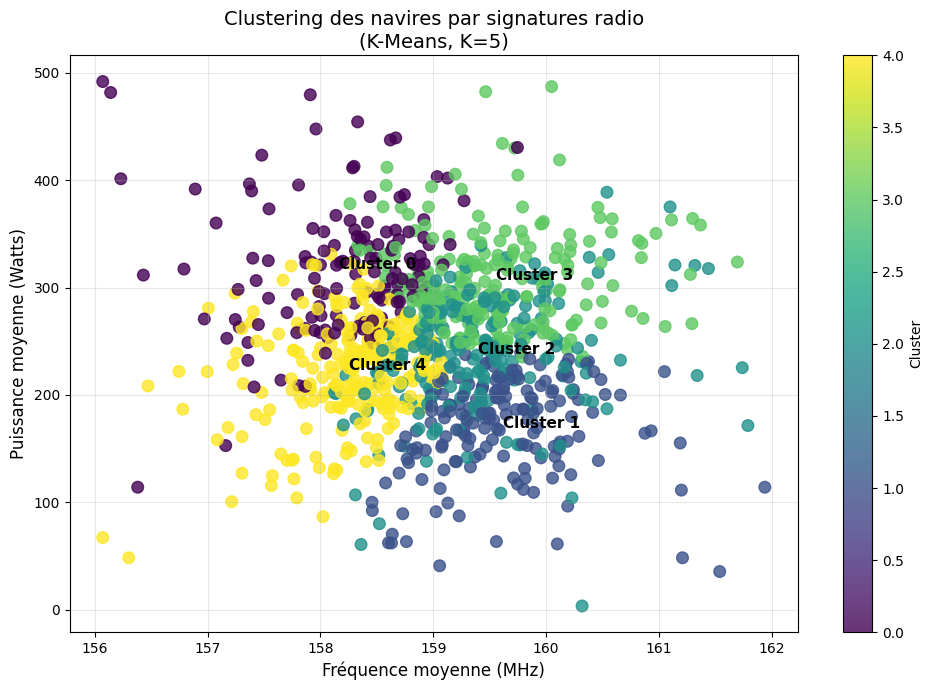


Fichier 'ship_radio_profiles_with_clusters.csv' sauvegardé avec la colonne cluster.


In [12]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# ====================== 1. Chargement des données ======================
# On utilise le fichier agrégé créé précédemment (recommandé)
print("Chargement des profils navires...")
profiles = pd.read_csv('ship_radio_profiles.csv')

print(f"Nombre de navires à clusteriser : {len(profiles)}")

# ====================== 2. Préparation des features ======================
features = ['freq_mean_mhz', 'bandwidth_mean_khz', 'power_mean_watts']

X = profiles[features].copy()

# Standardisation (très important pour K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ====================== 3. Clustering K-Means avec K=5 ======================
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
profiles['cluster'] = kmeans.fit_predict(X_scaled)

# ====================== 4. Résultats des clusters ======================
cluster_summary = profiles['cluster'].value_counts().sort_index()
print("\n=== Répartition des navires par cluster (K=5) ===")
print(cluster_summary)

# Statistiques par cluster
stats = profiles.groupby('cluster')[features].mean().round(3)
stats['nombre_navires'] = cluster_summary
print("\nMoyennes par cluster :")
print(stats)

# ====================== 5. Visualisation 2D (frequency vs power) ======================
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    profiles['freq_mean_mhz'], 
    profiles['power_mean_watts'],
    c=profiles['cluster'],
    cmap='viridis',
    s=70,
    alpha=0.8
)

plt.xlabel('Fréquence moyenne (MHz)', fontsize=12)
plt.ylabel('Puissance moyenne (Watts)', fontsize=12)
plt.title('Clustering des navires par signatures radio\n(K-Means, K=5)', fontsize=14)

# Ajout des labels des clusters
for i in range(5):
    cluster_data = profiles[profiles['cluster'] == i]
    plt.annotate(f'Cluster {i}', 
                 (cluster_data['freq_mean_mhz'].mean(), 
                  cluster_data['power_mean_watts'].mean()),
                 fontsize=11, weight='bold')

plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ====================== Sauvegarde ======================
profiles.to_csv('ship_radio_profiles_with_clusters.csv', index=False)
print("\nFichier 'ship_radio_profiles_with_clusters.csv' sauvegardé avec la colonne cluster.")